# Predição de ativos da bolsa de valores

## Import Libraries

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import plot
import plotly.graph_objects as go

import datetime
import pandas as pd
from sklearn.utils import class_weight
import utils


In [2]:
import xgboost as xgb
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras

In [3]:
import tensorflow as tf

print("Versão do TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.15.0
GPUs disponíveis: []


In [4]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import scrapingHistoricalData, FeaturesDataGenerator

import  ProcessingPipeline as pp


## Init parameters

In [5]:
# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', ]
                    #'Volume_log','Chaikin_Money_Flow', 'Williams_R,'PPO',]


# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low',
                    
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
 
                    'RSI_14' ,
                    'MACD', 'MACD_Signal', 'MACD_Histogram',
 
                    'Stochastic_K', 'Stochastic_D',
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC']  

features_indicators=[ 'Close', 'Open', 'High', 'Low', 'Volume','Volume_log',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow']

features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD']
                     #'CCI',  'ROC', 'Chaikin_Money_Flow']


In [6]:


pred_days = 45
#pred_days = 11
buy_sell_threshold=[0.05,-0.05]
lookback = 20
batch_size = 128
shuffle = False

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)



In [7]:
input_shape

(20, 5)

## Deep Learning Model

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Dense, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

In [9]:
# Camada de atenção 2D
@tf.keras.utils.register_keras_serializable(package="Custom", name="Attention2D")
class Attention2D(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super(Attention2D, self).__init__(**kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, inputs):
        # Compute attention scores
        score = tf.nn.tanh(self.W(inputs))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        
        # Apply attention weights to input
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)
        
        return context_vector

    @classmethod
    def from_config(cls, config):
        return cls(**config)
    

@tf.keras.utils.register_keras_serializable(package="Custom", name="Attention1D")
class Attention1D(tf.keras.layers.Layer):
    def __init__(self, units,  **kwargs):
        super(Attention1D, self).__init__( **kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def build(self, input_shape):
        self.W.build(input_shape)
        self.V.build(input_shape)

    def call(self, inputs):
        # Compute attention scores
        score = tf.nn.tanh(self.W(inputs))
        attention_weights = tf.nn.softmax(self.V(score), axis=-1)

        # Apply attention weights to input
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=-1)

        return context_vector

    @classmethod
    def from_config(cls, config):
        return cls(**config)
    

# Bloco ResNet
def resnet_block(x, filters, kernel_size, strides, padding):
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, strides=(1, 1), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    shortcut = x
    return keras.layers.Add()([x, shortcut])

In [ ]:
# Camadas comuns em 2D
def common_layers(input_layer, dropout_rate):
    x = Conv2D(32, kernel_size=(1, 2), activation='relu')(input_layer)
    x = Conv2D(64, kernel_size=(1, 3), activation='relu')(x)
    x = MaxPooling2D(pool_size=(1, 2))(x)
    return x


# Camada head em 2D
def head_layer(conv_layer, num_classes, dropout_rate, l2_regularization, activation='linear', output_name=None):
    x = Flatten()(conv_layer)
    # Camadas densas com regularização L2
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(num_classes,  activation=activation, name=output_name)(x)
    return x


# Criando o modelo completo
def create_model_2d(input_shape, num_classes, dropout_rate=0.2, l2_regularization=0.01):
    input_layer = Input(shape=input_shape)

    # Camadas comuns
    features = common_layers(input_layer, dropout_rate)

    # Head de classificação
    classification_output = head_layer(
        features, 
        num_classes=num_classes, 
        dropout_rate=dropout_rate, 
        l2_regularization=l2_regularization, 
        activation='softmax', 
        output_name='classification_head'
    )

    # Modelo final
    model = Model(inputs=input_layer, outputs=[classification_output], name="CNN_MultiHead_2D")
    return model


# Definindo parâmetros
input_shape_model = (1, input_shape[1], input_shape[0])  # Exemplo: imagens RGB de 128x128
num_classes = 3
dropout_rate = 0.5
l2_regularization = 0.01

# Criando o modeloa
model_CNN_MultiHead = create_model_2d(input_shape_model, num_classes, dropout_rate, l2_regularization)

# Resumo do modelo
model_CNN_MultiHead.summary()
list_of_models=[model_CNN_MultiHead]

In [11]:
# Camadas comuns em 2D
def common_layers(input_layer, dropout_rate):
    x = Conv2D(64, (3, 3), padding="same")(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=1, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    x = resnet_block(x, 128, (3, 3), (1, 1), 'same')
    x = resnet_block(x, 128, (3, 3), (1, 1), 'same')
    
    x = Conv2D(128, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    return x


# Camada head em 2D
def head_layer(conv_layer, num_classes, dropout_rate, l2_regularization, activation='linear', output_name=None):
    x = Conv2D(264, (3, 3), padding="same")(conv_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    # Atenção
    #x = Attention2D(units=32)(x)
    #x = Attention1D(units=264)(x)
    x = Flatten()(x)
    # Camadas densas com regularização L2
    x = Dense(256, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x


# Criando o modelo completo
def create_model_2d(input_shape, num_classes, dropout_rate=0.2, l2_regularization=0.01):
    input_layer = Input(shape=input_shape)

    # Camadas comuns
    features = common_layers(input_layer, dropout_rate)

    # Head de classificação
    classification_output = head_layer(
        features, 
        num_classes=num_classes, 
        dropout_rate=dropout_rate, 
        l2_regularization=l2_regularization, 
        activation='softmax', 
        output_name='classification_head'
    )

    # Modelo final
    model = Model(inputs=input_layer, outputs=[classification_output], name="CNN_MultiHead_2D")
    return model


# Definindo parâmetros
input_shape_model = (1, input_shape[1], input_shape[0])  # Exemplo: imagens RGB de 128x128
num_classes = 3
dropout_rate = 0.2
l2_regularization = 0.01

# Criando o modeloa
model_CNN_MultiHead = create_model_2d(input_shape_model, num_classes, dropout_rate, l2_regularization)

# Resumo do modelo
model_CNN_MultiHead.summary()
list_of_models=[model_CNN_MultiHead]

Model: "CNN_MultiHead_2D"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1, 5, 20)]           0         []                            
                                                                                                  
 conv2d_2 (Conv2D)           (None, 1, 5, 64)             11584     ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 1, 5, 64)             256       ['conv2d_2[0][0]']            
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 1, 5, 64)             0         ['batch_normali

Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1, 5, 20)]        0         
                                                                 
 conv2d_9 (Conv2D)           (None, 1, 4, 32)          1312      
                                                                 
 conv2d_10 (Conv2D)          (None, 1, 2, 64)          6208      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 1, 1, 64)          0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 128)               8320      
                                                  

In [13]:
#Metrics and Loss Functions  

from tensorflow.keras import backend as K

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  K.sum(K.square( y_true-y_pred ))
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot - K.epsilon()) )

def NRMSE(y_true, y_pred): # normalized_root_mean_squared_error
    return 1-K.sqrt(K.mean(K.square(y_pred - y_true))) 

MSE= tf.keras.losses.mean_squared_error
MAE = tf.keras.losses.mean_absolute_error
MAPE = tf.keras.losses.mean_absolute_percentage_error

In [14]:
#Optimizers
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    #optimizer = optimizers.SGD(lr=params["lr"], decay=1e-6, momentum=0.9, nesterov=True)

    return optimizer1
    #

#Train options callbacks

    # Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

    # verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.01, patience = 5, min_lr=1e-20,verbose=1)



def checkpoints(model_name):
    checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback

model_name = 'CNN_MultiHead_2D'

In [15]:
f'models/model_{model_name}_crypto_lookback_{lookback}'

'models/model_CNN_MultiHead_2D_crypto_lookback_20'

In [16]:
list_of_models=[model_CNN_MultiHead]

In [17]:
for model in list_of_models:
    model.summary()

Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1, 5, 20)]        0         
                                                                 
 conv2d_9 (Conv2D)           (None, 1, 4, 32)          1312      
                                                                 
 conv2d_10 (Conv2D)          (None, 1, 2, 64)          6208      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 1, 1, 64)          0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 128)               8320      
                                                  

## Load Data And train

In [18]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
interval = '4h'

#df=SHD.get_crypto_historical_data(cryptos, interval, '2015-01-01')


In [19]:
import datetime
init_date = '2017-01-01'
#init_date = '2020-01-01'
init_date_object = datetime.datetime.strptime(init_date, '%Y-%m-%d').date()

date_now = datetime.date.today()

diff_years = date_now.year - init_date_object.year
year_window = 6


#cryptos_list = [ 'BTC','ETH','SOL','DOT','FET']/ 
cryptos_list = ['BTC']

if year_window > diff_years:
    raise ValueError("O intervalo de anos (year_window) é maior do que o período disponível nos dados.")


In [20]:

# Caminho do arquivo
file_folder = f'Data_history/{cryptos_list[0]}_{interval}.csv'

BTC Dataset Period:2017-01-01 : 2023-01-01


Donwload the file Data_history/BTC_4h.csv from bincance history.
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (8662,)
Vall data shape (1084,)
Test data shape (1084,)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide



self.pred_days 45


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:936: RuntimeWarning:

divide by zero encountered in log



input data shape (8642, 20, 5)
output data shape (8642, 3)
self.pred_days 45
input data shape (1064, 20, 5)
output data shape (1064, 3)
self.pred_days 45
input data shape (1064, 20, 5)
output data shape (1064, 3)
[0 1 2] [5962 1360 1320]
[0.4831712  2.11813725 2.18232323]
Training model : models/model_CNN_MultiHead_2D_crypto_lookback_20
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead_2D
Epoch 1/200



Epoch 1: val_loss improved from inf to 0.80586, saving model to models\model_CNN_MultiHead_2D_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_20\assets


67/67 - 13s - loss: 0.9756 - accuracy: 0.5238 - matthews_correlation_coefficient: 0.1197 - val_loss: 0.8059 - val_accuracy: 0.6533 - val_matthews_correlation_coefficient: 0.0522 - lr: 1.0000e-04 - 13s/epoch - 191ms/step
Epoch 2/200

Epoch 2: val_loss improved from 0.80586 to 0.76313, saving model to models\model_CNN_MultiHead_2D_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_20\assets


67/67 - 3s - loss: 0.8210 - accuracy: 0.6383 - matthews_correlation_coefficient: 0.2900 - val_loss: 0.7631 - val_accuracy: 0.6465 - val_matthews_correlation_coefficient: 0.3012 - lr: 1.0000e-04 - 3s/epoch - 50ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 0.76313
67/67 - 1s - loss: 0.6974 - accuracy: 0.6685 - matthews_correlation_coefficient: 0.4243 - val_loss: 0.7649 - val_accuracy: 0.6855 - val_matthews_correlation_coefficient: 0.4140 - lr: 1.0000e-04 - 1s/epoch - 22ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 0.76313
67/67 - 2s - loss: 0.5911 - accuracy: 0.7108 - matthews_correlation_coefficient: 0.5386 - val_loss: 0.7878 - val_accuracy: 0.6729 - val_matthews_correlation_coefficient: 0.4987 - lr: 1.0000e-04 - 2s/epoch - 32ms/step
Epoch 5/200

Epoch 5: val_loss did not improve from 0.76313
67/67 - 2s - loss: 0.4995 - accuracy: 0.7583 - matthews_correlation_coefficient: 0.6298 - val_loss: 0.8237 - val_accuracy: 0.6729 - val_matthews_correlation_coefficient:

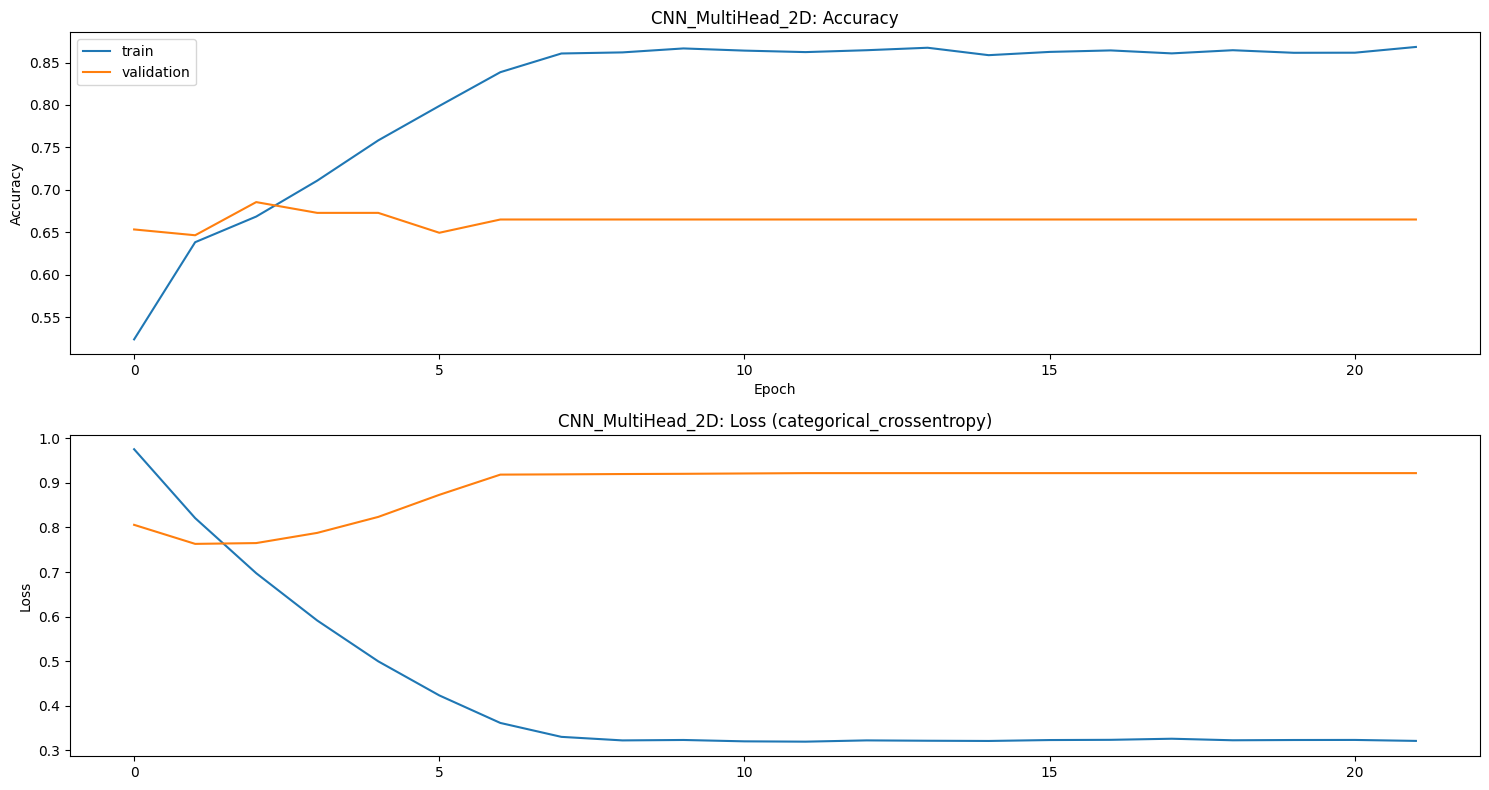

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead_2D



Model name: CNN_MultiHead_2D
34/34 [==============================] - 0s 3ms/step
CNN_MultiHead_2D  classification Accuracy 0.5150375939849624
BTC Dataset Period:2018-01-01 : 2024-01-01
Donwload the file Data_history/BTC_4h.csv from bincance history.
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (9600,)
Vall data shape (1200,)
Test data shape (1202,)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide



self.pred_days 45
input data shape (9580, 20, 5)
output data shape (9580, 3)
self.pred_days 45
input data shape (1180, 20, 5)
output data shape (1180, 3)
self.pred_days 45
input data shape (1182, 20, 5)
output data shape (1182, 3)
[0 1 2] [6724 1400 1456]
[0.47491572 2.28095238 2.19322344]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead_2D
Epoch 1/200

Epoch 1: val_loss did not improve from 0.76313
74/74 - 4s - loss: 0.9294 - accuracy: 0.5102 - matthews_correlation_coefficient: 0.1780 - val_loss: 0.9057 - val_accuracy: 0.4314 - val_matthews_correlation_coefficient: 0.0379 - lr: 1.0000e-04 - 4s/epoch - 49ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 0.76313
74/74 - 2s - loss: 0.7986 - accuracy: 0.5717 - matthews_correlation_coefficient: 0.3095 - val_loss: 0.9385 - val_accuracy: 0.4557 - val_matthews_correlation_coeff

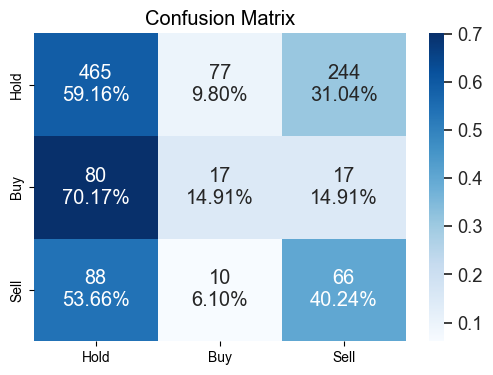

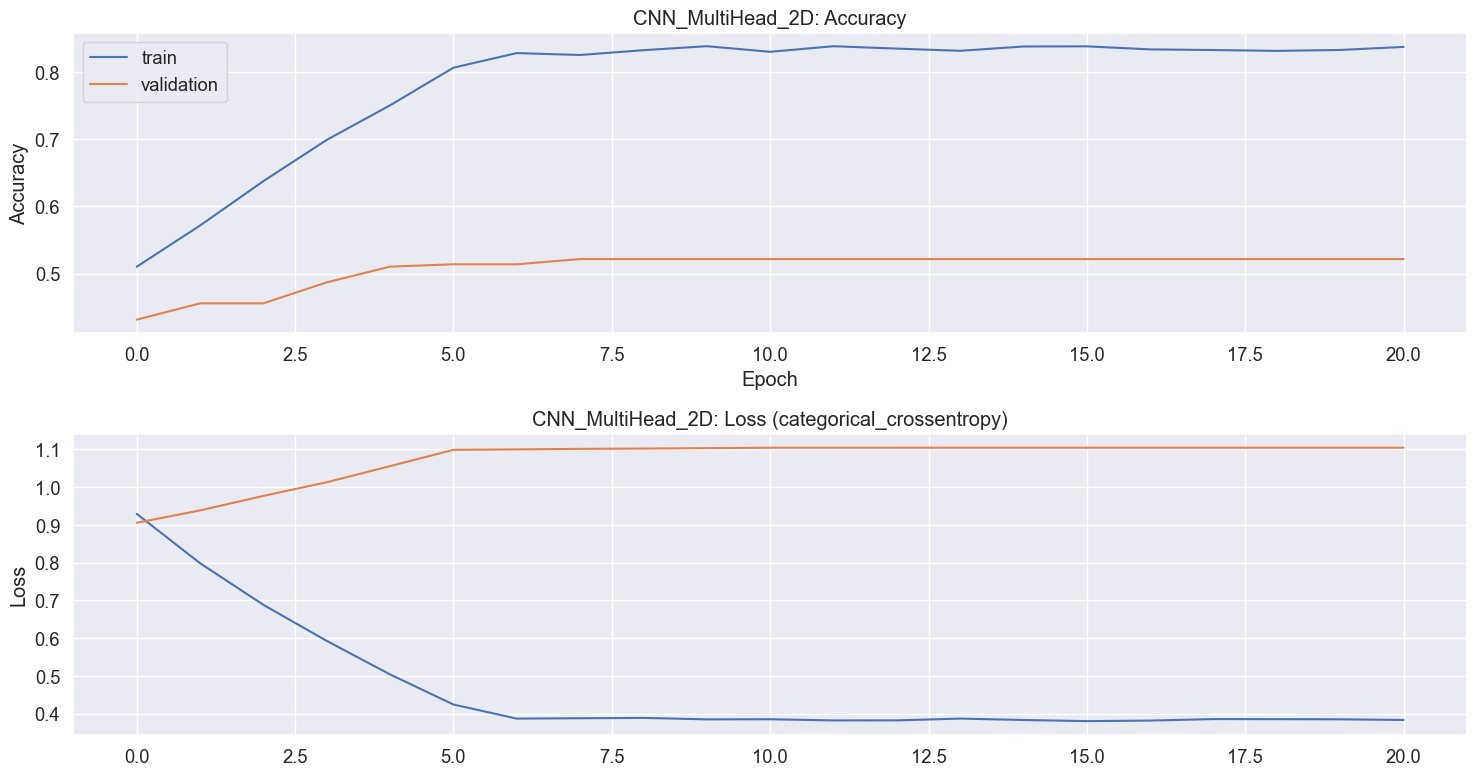

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead_2D
Model name: CNN_MultiHead_2D
37/37 [==============================] - 0s 2ms/step
CNN_MultiHead_2D  classification Accuracy 0.4906937394247039
BTC Dataset Period:2019-01-01 : 2025-01-28
Donwload the file Data_history/BTC_4h.csv from bincance history.
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (9714,)
Vall data shape (1214,)
Test data shape (1216,)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:109: RuntimeWarning:

invalid value encountered in divide



self.pred_days 45
input data shape (9694, 20, 5)
output data shape (9694, 3)
self.pred_days 45
input data shape (1194, 20, 5)
output data shape (1194, 3)
self.pred_days 45
input data shape (1196, 20, 5)
output data shape (1196, 3)
[0 1 2] [6939 1402 1353]
[0.46567709 2.30480266 2.38827297]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead_2D
Epoch 1/200

Epoch 1: val_loss improved from 0.76313 to 0.69792, saving model to models\model_CNN_MultiHead_2D_crypto_lookback_20
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_20\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_lookback_20\assets


75/75 - 6s - loss: 0.7693 - accuracy: 0.6195 - matthews_correlation_coefficient: 0.3312 - val_loss: 0.6979 - val_accuracy: 0.7344 - val_matthews_correlation_coefficient: 0.5138 - lr: 1.0000e-04 - 6s/epoch - 75ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 0.69792
75/75 - 2s - loss: 0.6394 - accuracy: 0.7477 - matthews_correlation_coefficient: 0.5663 - val_loss: 0.7026 - val_accuracy: 0.7057 - val_matthews_correlation_coefficient: 0.5326 - lr: 1.0000e-04 - 2s/epoch - 23ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 0.69792
75/75 - 2s - loss: 0.5302 - accuracy: 0.7965 - matthews_correlation_coefficient: 0.6662 - val_loss: 0.7391 - val_accuracy: 0.6979 - val_matthews_correlation_coefficient: 0.5617 - lr: 1.0000e-04 - 2s/epoch - 29ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 0.69792
75/75 - 2s - loss: 0.4310 - accuracy: 0.8397 - matthews_correlation_coefficient: 0.7393 - val_loss: 0.8122 - val_accuracy: 0.7057 - val_matthews_correlation_coefficient:

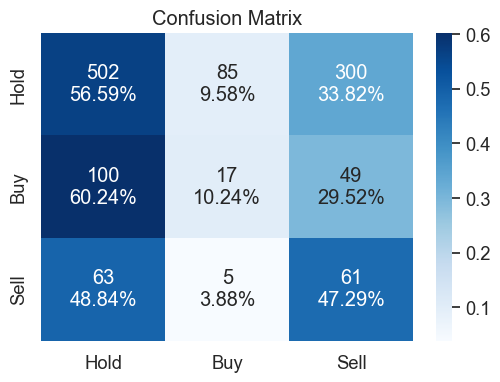

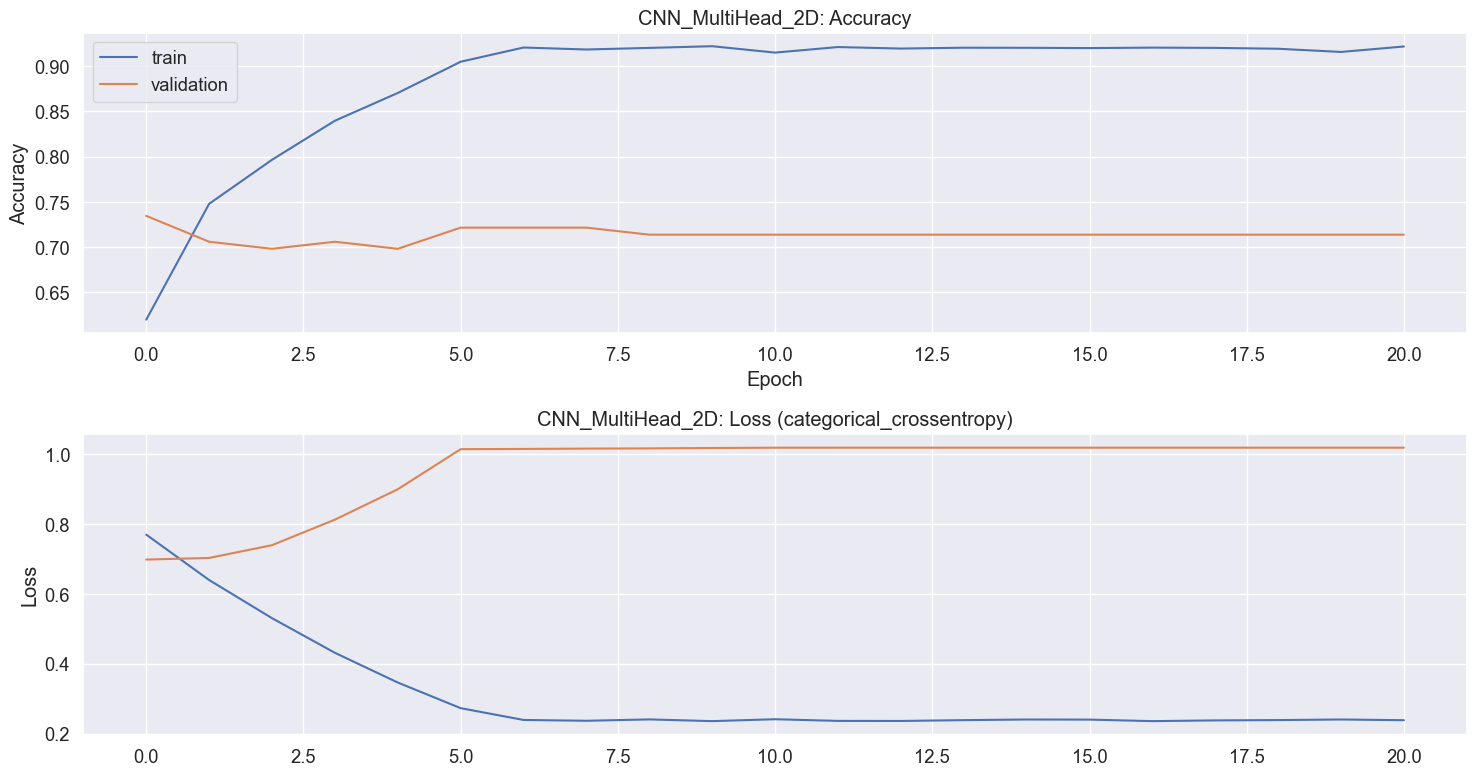

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead_2D
Model name: CNN_MultiHead_2D
38/38 [==============================] - 0s 3ms/step
CNN_MultiHead_2D  classification Accuracy 0.5911371237458194


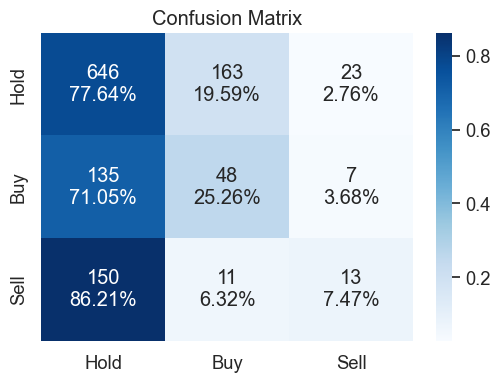

In [21]:
idx=0
for i, cryptos in enumerate(cryptos_list):

    for stride_year in range(0, diff_years-year_window+1):
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 

        
        if os.path.exists(file_folder):
            print(f"The file {file_folder} exist in folder path.")
            cryptos_df=pd.read_csv(file_folder, index_col=0)

            mask = (cryptos_df['Date'] >= init_time) & (cryptos_df['Date'] <= end_time)
            cryptos_df = cryptos_df[mask]

        else:
            print(f"Donwload the file {file_folder} from bincance history.")
            # Obtenha os dados históricos
            cryptos_df = SHD.get_crypto_historical_data([cryptos], interval, init_time, end_time)
        
        # split the data in train validation and test
        split_data=FeaturesDataGenerator().split_data
        X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
        X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

        print('Train data shape',X_train.shape)
        print('Vall data shape',X_val.shape)
        print('Test data shape',X_test.shape)

        # get train vall and test dataloader
        X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
        X_data_gen_val = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_val)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
        X_data_gen_test = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_test)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])

        # get classes weigths 
        Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
        n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
        print(n_classes, counts)
        output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

        # Ajusta o peso da primeira classe
        #adjustment_factor = 2
        #output_class_weights[2] = output_class_weights[2] * adjustment_factor

        # Normaliza os pesos novamente
        #output_class_weights = output_class_weights / np.sum(output_class_weights)
        print(output_class_weights)
        #output_class_weights = np.ones(3) 
        weighted_categorical_crossentropy_loss= X_data_gen_train.weighted_categorical_crossentropy(output_class_weights)

        loss = weighted_categorical_crossentropy_loss

        for idx_model, model in enumerate(list_of_models):

            if idx == 0:  
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name)
                model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy',matthews_correlation_coefficient])
                idx=1
            else:
                model = trained_best_models[model._name]

            print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
            print(f'Initing train fo model: {model._name}')

            history = model.fit(
                X_data_gen_train,
                epochs=200,
                callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
                validation_data=X_data_gen_val,
                #shuffle=True,
                verbose=2
            )
            # Assuming history_metric, history_metric_val, history are defined elsewhere

            fig, axes = plt.subplots(2, 1, figsize=(15, 8))  # Create subplots programmatically

            # Plot accuracy, sharing x-axis with NRMSE
            axes[0].plot(history.history['accuracy'])
            axes[0].plot(history.history['val_accuracy'])
            axes[0].set_title(f'{model._name}: Accuracy')
            axes[0].set_ylabel('Accuracy')
            axes[0].set_xlabel('Epoch')  # Shared x-axis label
            axes[0].legend(['train', 'validation'], loc='upper left')

            # Plot loss
            axes[1].plot(history.history['loss'])
            axes[1].plot(history.history['val_loss'])
            axes[1].set_title(f'{model._name}: Loss (categorical_crossentropy)')
            axes[1].set_ylabel('Loss')

            # Adjust spacing and margins (optional)
            plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

            # Fine-tune spacing (optional)
            plt.tight_layout()

            plt.show()
        trained_best_models={}
        print("---------------------------------------------------------------------------------------------------------------------------------")
        for model in list_of_models:
            print(model.name)
            checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
            trained_best_models[f'{model._name}']=tf.keras.models.load_model(
                checkpoint_filepath, 
                custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient}, compile=True)

            print('Model name:',model_name)

            x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)
            x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
            
            label_pred = trained_best_models[model_name].predict(x_data)
            print(model_name,' classification Accuracy',
                            utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                            np.argmax(label_pred,axis=1),average="micro"))

            cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
            
            try:
                utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
            except:
                print(cf_matrix)


Model name: CNN_MultiHead_2D
38/38 [==============================] - 0s 2ms/step
CNN_MultiHead_2D  classification Accuracy 0.5911371237458194


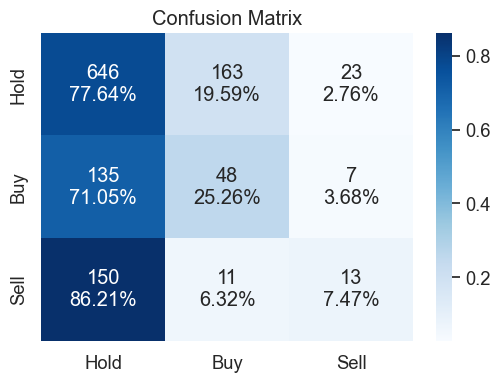

In [22]:
import utils
model_name = "CNN_MultiHead"    
for model_name in list_of_models:
    model_name = model_name._name
    print('Model name:',model_name)

    x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
    
    label_pred = trained_best_models[model_name].predict(x_data)
    print(model_name,' classification Accuracy',
                    utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                    np.argmax(label_pred,axis=1),average="micro"))

    cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
    
    try:
        utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
    except:
        print(cf_matrix)

Model name: CNN_MultiHead_2D
38/38 [==============================] - 0s 3ms/step
CNN_MultiHead_2D  classification Accuracy 0.6113902847571189


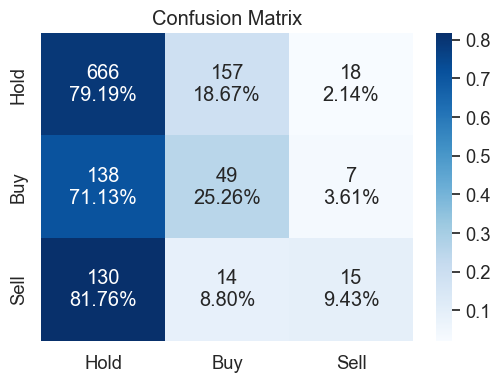

In [23]:
model_name = "CNN_MultiHead_2D"  
print('Model name:',model_name)

x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_val.features, min_norm,  max_norm, axis=0)
x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])

label_pred = trained_best_models[model_name].predict(x_data)
print(model_name,' classification Accuracy',
                utils.f1_score(np.argmax(X_data_gen_val.y_classification,axis=1),
                np.argmax(label_pred,axis=1),average="micro"))

cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_val.y_classification,axis=1),np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

In [24]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data, transaction_cost=0.0001):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []
        self.transaction_cost = transaction_cost
        self.trades = []

    def execute_trade(self, signal, price):
        if signal == 'Buy':
            if self.balance > 0:
                cost = self.balance * self.transaction_cost
                self.position = (self.balance - cost) / price
                self.trades.append({'Action': 'Buy', 'Price': price, 'Position': self.position})
                self.balance = 0
        
        elif signal == 'Sell':
            if self.position > 0:
                proceeds = self.position * price
                cost = proceeds * self.transaction_cost
                self.balance = proceeds - cost
                self.trades.append({'Action': 'Sell', 'Price': price, 'Balance': self.balance})
                self.position = 0

        elif signal not in ['Hold']:
            print('balance:',self.balance)
            print('positi:',self.position)
            raise ValueError(f"Invalid signal: {signal}")

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]
            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_portfolio_value(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.portfolio_value, label='Portfolio Value')
        plt.title('Portfolio Value Over Time')
        plt.xlabel('Time')
        plt.ylabel('Portfolio Value')
        plt.legend()
        plt.show()

    def calculate_metrics(self):
        final_portfolio_value = self.portfolio_value[-1]
        roi = (final_portfolio_value - self.initial_balance) / self.initial_balance * 100
        max_drawdown = min(self.portfolio_value) / self.initial_balance - 1
        return {
            'Final Portfolio Value': final_portfolio_value,
            'ROI (%)': roi,
            'Max Drawdown (%)': max_drawdown * 100
        }

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')
        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

self.pred_days 45
input data shape (10128, 20, 5)
output data shape (10128, 3)
317/317 [==============================] - 1s 3ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([2050, 7692,  386], dtype=int64))


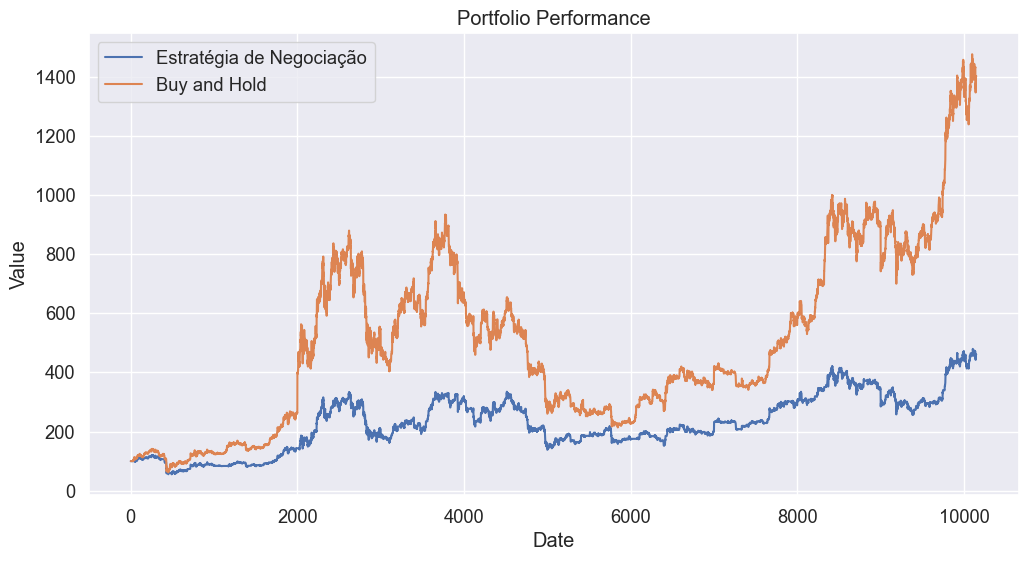

Retorno da Estratégia de Negociação: 360.59%
Retorno da Estratégia de Buy and Hold: 1301.52%


In [25]:
# Parâmetros iniciais
symbol=['BTC']
#symbol = cryptos_list[0]
interval = '4h'
start_time = '2020-01-01'
initial_balance = 100

# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

dataGen_inference = FeaturesDataGenerator(data, datatype = '2D', lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
    
    # list_of_models = ['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name='CNN_MultiHead_2D'
    label_pred = trained_best_models[model_name].predict(x_data)

    signals_model = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    print(np.unique(signals_model, return_counts=True))

    init_signals= ['Hold']*lookback
    
    #trade_signals=init_signals + generate_signals(signals_model)

    trade_signals = init_signals + signals_model
    

    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    # backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals =  init_signals + ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

In [26]:
print(f"Modelo: {backtester.calculate_metrics()}")
print(f"BuyHold: {buy_and_hold.calculate_metrics()}")

Modelo: {'Final Portfolio Value': 460.58554680583484, 'ROI (%)': 360.58554680583484, 'Max Drawdown (%)': -44.27453049189866}
BuyHold: {'Final Portfolio Value': 1401.5211278206762, 'ROI (%)': 1301.5211278206762, 'Max Drawdown (%)': -37.77462613389309}


10148
Calculating labels


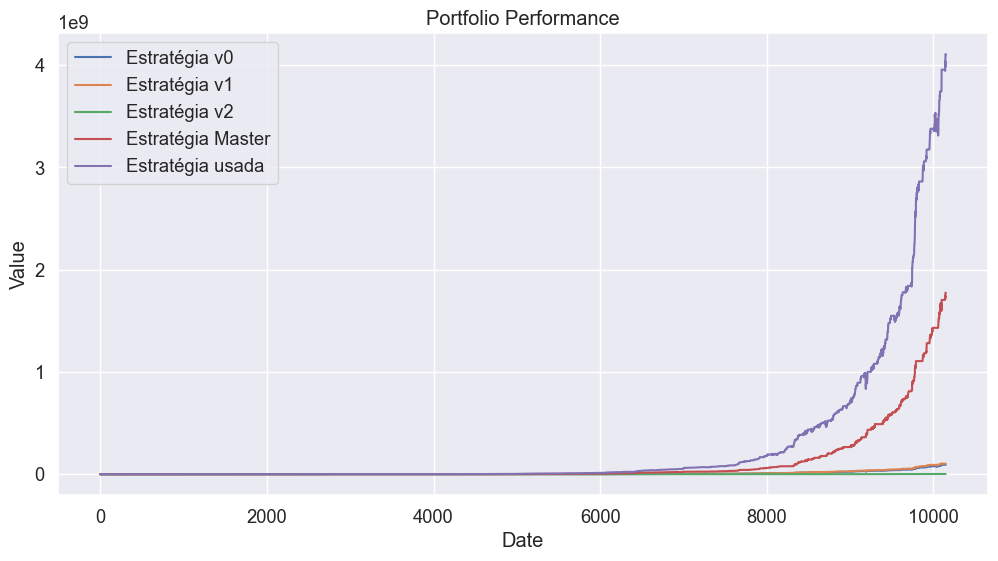

Estratégia v0: 93327400.61%
Estratégia v1: 103830057.77%
Estratégia v2: 2520201.08%
Estratégia Master: 1775243895.15%
Estratégia Master Testada: 4106999937.63%


In [27]:
# Implementar todas as estratégias
label_data_v0 = dataGen_inference.label_data_v0(close_prices=data['Close'].values, window=pred_days)
label_data_v1 = dataGen_inference.label_data_v1(close_prices=data['Close'].values, window=pred_days)
label_data_v2 = dataGen_inference.label_data__(close_prices=data['Close'].values, window=pred_days)
label_data_master = dataGen_inference.label_data_master(close_prices=data['Close'].values, window=pred_days)
label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=pred_days)

# Convertar as labels em sinais de compra e venda
trade_signals_v0 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v0]
trade_signals_v1 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v1]
trade_signals_v2 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v2]
trade_signals_master = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_master]
trade_signals = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data]

# Realizar o backtest
backtester_v0 = Backtester(initial_balance, data)
backtester_v0.run(trade_signals_v0)

backtester_v1 = Backtester(initial_balance, data)
backtester_v1.run(trade_signals_v1)

backtester_v2 = Backtester(initial_balance, data)
backtester_v2.run(trade_signals_v2)

backtester_master = Backtester(initial_balance, data)
backtester_master.run(trade_signals_master)

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester_v0.data.index, backtester_v0.portfolio_value, label='Estratégia v0')
plt.plot(backtester_v1.data.index, backtester_v1.portfolio_value, label='Estratégia v1')
plt.plot(backtester_v2.data.index, backtester_v2.portfolio_value, label='Estratégia v2')
plt.plot(backtester_master.data.index, backtester_master.portfolio_value, label='Estratégia Master')
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia usada')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular o retorno de cada estratégia
retorno_v0 = (backtester_v0.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v1 = (backtester_v1.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v2 = (backtester_v2.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master = (backtester_master.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master_tested = (backtester.portfolio_value[-1] - initial_balance) / initial_balance

# Imprimir os resultados
print(f"Estratégia v0: {retorno_v0 * 100:.2f}%")
print(f"Estratégia v1: {retorno_v1 * 100:.2f}%")
print(f"Estratégia v2: {retorno_v2 * 100:.2f}%")
print(f"Estratégia Master: {retorno_master * 100:.2f}%")
print(f"Estratégia Master Testada: {retorno_master_tested * 100:.2f}%")